# 01 — Exploratory Data Analysis di CodeChat V2.0

Questo notebook contiene una prima analisi esplorativa del dataset **CodeChat V2.0**.  
L'obiettivo è capire quali dimensioni del dataset siano effettivamente utili per una tesi che mette in relazione la qualità dei prompt reali con il technical debt nel codice generato dagli LLM.

In questa fase non modifico i campi originali del dataset: costruisco soltanto viste ausiliarie e tabelle di supporto per descrivere il dataset.

## 0. Setup dell'ambiente

In questa sezione preparo l'ambiente di lavoro e centralizzo la configurazione del notebook.  
Il dataset è grande, quindi separo le operazioni leggere sulle colonne tabellari dalle ispezioni sulle colonne annidate.

In [1]:
# Se necessario, eseguire questa cella una sola volta.
# %pip install -q datasets pandas numpy matplotlib tqdm pyarrow langdetect

from __future__ import annotations

import json
import hashlib
import re
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from datasets import Dataset, DatasetDict, concatenate_datasets, load_dataset
from tqdm.auto import tqdm

try:
    from langdetect import DetectorFactory, LangDetectException, detect
    DetectorFactory.seed = 42
    LANGDETECT_AVAILABLE = True
except ImportError:
    LANGDETECT_AVAILABLE = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 160)

DATASET_ID = "Suzhen/CodeChat-V2.0"
RANDOM_SEED = 42

# Uso un campione solo per stampare esempi leggibili: tutte le statistiche principali sono calcolate sul dataset completo.
N_EXAMPLES = 3

OUTPUT_DIR = Path("outputs")
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
DATA_DIR = OUTPUT_DIR / "data"

for directory in [OUTPUT_DIR, FIGURES_DIR, TABLES_DIR, DATA_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


C:\Users\franc\PycharmProjects\Prompt-Quality-Technical-Debt-Thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Caricamento del dataset completo

Carico il dataset da Hugging Face mantenendo la struttura originale.  
Se il dataset contiene più split, li conservo in `raw_ds` e creo anche una vista unificata `full_ds` per le analisi aggregate.

In [2]:
raw_ds = load_dataset(DATASET_ID)
raw_ds

DatasetDict({
    train: Dataset({
        features: ['conversation_id', 'model', 'conversation', 'turn', 'snippet_turns'],
        num_rows: 587568
    })
})

In [3]:
def to_single_dataset(ds: Dataset | DatasetDict) -> Dataset:
    """Creo una vista unica del dataset senza alterare i campi originali."""
    if isinstance(ds, DatasetDict):
        return concatenate_datasets([split_ds for split_ds in ds.values()])
    return ds

full_ds = to_single_dataset(raw_ds)

print(f"Numero totale di record: {full_ds.num_rows:,}")
print(f"Numero di colonne: {full_ds.num_columns}")
print(f"Colonne: {full_ds.column_names}")

Numero totale di record: 587,568
Numero di colonne: 5
Colonne: ['conversation_id', 'model', 'conversation', 'turn', 'snippet_turns']


## 2. Analisi ad alto livello di feature e dimensioni

In questa sezione verifico schema, dimensioni e tipi delle feature.  
Questa è la prima verifica di coerenza rispetto alla struttura attesa: `conversation_id`, `model`, `conversation`, `turn`, `snippet_turn`.

In [4]:
expected_columns = ["conversation_id", "model", "conversation", "turn", "snippet_turns"]
snippet_turn_column = "snippet_turns" if "snippet_turns" in full_ds.column_names else "snippet_turn"

schema_summary = pd.DataFrame({
    "column": full_ds.column_names,
    "feature_type": [str(full_ds.features[col]) for col in full_ds.column_names],
    "is_expected": [col in expected_columns or col == "snippet_turn" for col in full_ds.column_names],
})

schema_summary


,column,feature_type,is_expected
0,conversation_id,Value('string'),True
1,model,Value('string'),True
2,conversation,"List(List({'role': Value('string'), 'content': Value('string'), 'language': Value('string'), 'timestamp': Value('timestamp[ms]')}))",True
3,turn,Value('int64'),True
4,snippet_turns,List(Value('int64')),True


In [5]:
dataset_size_summary = pd.DataFrame({
    "metric": [
        "n_records",
        "n_columns",
        "expected_columns_present",
        "unexpected_columns",
        "missing_expected_columns",
    ],
    "value": [
        f"{full_ds.num_rows:,}",
        full_ds.num_columns,
        sorted([col for col in expected_columns if col in full_ds.column_names]),
        sorted([col for col in full_ds.column_names if col not in expected_columns]),
        sorted([col for col in expected_columns if col not in full_ds.column_names]),
    ],
})

dataset_size_summary

,metric,value
0,n_records,"587,568"
1,n_columns,5
2,expected_columns_present,"[conversation, conversation_id, model, snippet_turns, turn]"
3,unexpected_columns,[]
4,missing_expected_columns,[]


In [6]:
# Creo una tabella leggera con le colonne scalari principali.
# Non includo direttamente le colonne annidate più pesanti, così mantengo il notebook più gestibile.
scalar_columns = [col for col in ["conversation_id", "model", "turn"] if col in full_ds.column_names]
meta_df = full_ds.select_columns(scalar_columns).to_pandas()

meta_df.head()

,conversation_id,model,turn
0,84b76971d297c9d3b33edc6e6380ab4f,gpt-4-0314,1
1,bcdc32b84c55fbc6ed31b1432f36c8e4,gpt-4-0314,1
2,5b9dc4768868af6f7153b6821807ccb6,gpt-4-0314,1
3,d349f4b16352ac854beff5ca5b531424,gpt-4-0314,1
4,a53c32dad716ca5cacde9dbf35dd0ad1,gpt-4-0314,1


In [7]:
meta_df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 587568 entries, 0 to 587567
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   conversation_id  587568 non-null  str  
 1   model            587568 non-null  str  
 2   turn             587568 non-null  int64
dtypes: int64(1), str(2)
memory usage: 42.4 MB


### 2.1 Ispezione controllata delle colonne annidate

Prima di analizzare linguaggi e snippet, osservo pochi esempi reali delle colonne `conversation` e `snippet_turn`.  
Questa ispezione serve a capire la forma dei campi annidati senza trasformare il dataset originale.

In [8]:
for idx in range(min(N_EXAMPLES, full_ds.num_rows)):
    print("=" * 120)
    print(f"Esempio {idx}")
    for col in ["conversation_id", "model", "turn", "conversation", snippet_turn_column]:
        if col in full_ds.column_names:
            value = full_ds[idx][col]
            print(f"\n--- {col} ---")
            print(json.dumps(value, ensure_ascii=False, indent=2, default=str)[:3000])


Esempio 0

--- conversation_id ---
"84b76971d297c9d3b33edc6e6380ab4f"

--- model ---
"gpt-4-0314"

--- turn ---
1

--- conversation ---
[
  [
    {
      "role": "user",
      "content": "Write a script for Blender 3D version 3.5, so that you can align objects at the same distance from each other.",
      "language": "English",
      "timestamp": null
    },
    {
      "role": "assistant",
      "content": "Assuming you are looking for a Python script, that works with Blender 3D v3.5 API, to align objects in a line with equal spacing between them. Here's a script that should achieve this:\n\n```python\nimport bpy\nimport math\n\ndef align_objects(distance):\n    \n    # Get a list of selected objects in the scene\n    objects = [obj for obj in bpy.context.selected_objects]\n\n    # Calculate the number of objects - 1 (for the division count)\n    obj_amount = len(objects) - 1\n    \n    if obj_amount < 1:\n        print(\"Select at least two objects to align.\")\n        return False\

In [9]:
def collect_nested_keys(obj: Any, prefix: str = "", max_depth: int = 6) -> Counter:
    """Raccolgo le chiavi presenti nelle strutture annidate per capire quali metadati posso usare nell'EDA."""
    keys = Counter()
    if max_depth < 0:
        return keys

    if isinstance(obj, dict):
        for key, value in obj.items():
            path = f"{prefix}.{key}" if prefix else str(key)
            keys[path] += 1
            keys.update(collect_nested_keys(value, path, max_depth - 1))
    elif isinstance(obj, list):
        for item in obj[:20]:
            keys.update(collect_nested_keys(item, prefix, max_depth - 1))

    return keys

nested_key_counter = Counter()
sample_size_for_structure = min(1000, full_ds.num_rows)

for row in tqdm(full_ds.select(range(sample_size_for_structure)), desc="Analisi struttura annidata"):
    for col in ["conversation", snippet_turn_column]:
        if col in full_ds.column_names:
            nested_key_counter.update(collect_nested_keys(row[col], prefix=col))

nested_keys_df = (
    pd.DataFrame(nested_key_counter.items(), columns=["nested_key", "count_in_sample"])
    .sort_values("count_in_sample", ascending=False)
    .reset_index(drop=True)
)

nested_keys_df.head(50)


Analisi struttura annidata: 100%|██████████| 1000/1000 [00:00<00:00, 5685.13it/s]


,nested_key,count_in_sample
0,conversation.role,6654
1,conversation.content,6654
2,conversation.language,6654
3,conversation.timestamp,6654


## 3. Analisi preliminare delle problematiche del dataset

Qui controllo valori mancanti, cardinalità degli identificativi e possibili duplicati.  
Distinguo tra duplicati di `conversation_id`, duplicati esatti di record e duplicati del contenuto conversazionale.

In [10]:
def is_missing_value(value: Any) -> bool:
    """Definisco una nozione conservativa di valore mancante valida anche per liste e dizionari."""
    if value is None:
        return True
    if isinstance(value, float) and np.isnan(value):
        return True
    if isinstance(value, str) and value.strip() == "":
        return True
    if isinstance(value, (list, tuple, dict)) and len(value) == 0:
        return True
    return False

def count_missing_by_column(ds: Dataset, batch_size: int = 1000) -> pd.DataFrame:
    missing_counts = Counter()
    total = ds.num_rows

    for batch in tqdm(ds.iter(batch_size=batch_size), total=int(np.ceil(total / batch_size)), desc="Conteggio valori mancanti"):
        for col in ds.column_names:
            missing_counts[col] += sum(is_missing_value(value) for value in batch[col])

    result = pd.DataFrame({
        "column": ds.column_names,
        "missing_count": [missing_counts[col] for col in ds.column_names],
    })
    result["missing_pct"] = result["missing_count"] / total * 100
    return result.sort_values(["missing_count", "column"], ascending=[False, True]).reset_index(drop=True)

missing_summary = count_missing_by_column(full_ds)
missing_summary

Conteggio valori mancanti: 100%|██████████| 588/588 [00:31<00:00, 18.39it/s]


,column,missing_count,missing_pct
0,conversation,0,0.0
1,conversation_id,0,0.0
2,model,0,0.0
3,snippet_turns,0,0.0
4,turn,0,0.0


In [11]:
# Cardinalità e duplicati sulle colonne scalari.
cardinality_summary = []

for col in scalar_columns:
    n_unique = meta_df[col].nunique(dropna=True)
    cardinality_summary.append({
        "column": col,
        "n_unique": n_unique,
        "n_missing": meta_df[col].isna().sum(),
        "duplicate_values_count": len(meta_df) - n_unique if col == "conversation_id" else np.nan,
    })

cardinality_summary = pd.DataFrame(cardinality_summary)
cardinality_summary

,column,n_unique,n_missing,duplicate_values_count
0,conversation_id,587568,0,0.0
1,model,14,0,NaN
2,turn,115,0,NaN


In [12]:
if "conversation_id" in meta_df.columns:
    duplicated_ids = (
        meta_df.loc[meta_df["conversation_id"].duplicated(keep=False), "conversation_id"]
        .value_counts()
        .rename_axis("conversation_id")
        .reset_index(name="occurrences")
    )

    print(f"Numero di conversation_id duplicati: {len(duplicated_ids):,}")
    display(duplicated_ids.head(20))
else:
    print("La colonna conversation_id non è presente.")

Numero di conversation_id duplicati: 0


,conversation_id,occurrences


In [13]:
def stable_hash(value: Any) -> str:
    """Calcolo un hash stabile per confrontare strutture annidate senza salvare nuove colonne nel dataset originale."""
    serialized = json.dumps(value, ensure_ascii=False, sort_keys=True, default=str)
    return hashlib.sha256(serialized.encode("utf-8")).hexdigest()

USER_ROLE_VALUES = {"user", "human", "developer"}
ASSISTANT_ROLE_VALUES = {"assistant", "gpt", "chatgpt", "llm", "model"}
TEXT_FIELD_CANDIDATES = ["content", "text", "value", "message", "prompt"]
ROLE_FIELD_CANDIDATES = ["role", "from", "author", "speaker", "sender"]

def flatten_conversation(conversation: Any) -> list[Any]:
    """Rendo lineare la conversazione perché nel dataset i messaggi possono essere annidati per turno."""
    if conversation is None:
        return []
    if isinstance(conversation, dict):
        return [conversation]
    if isinstance(conversation, list):
        messages = []
        for item in conversation:
            messages.extend(flatten_conversation(item))
        return messages
    return [conversation]

def extract_text_from_message(message: Any) -> str:
    """Estraggo il testo principale da un messaggio mantenendo una logica conservativa e ispezionabile."""
    if message is None:
        return ""
    if isinstance(message, str):
        return message.strip()
    if isinstance(message, dict):
        for field in TEXT_FIELD_CANDIDATES:
            if field in message and isinstance(message[field], str):
                return message[field].strip()
        text_parts = []
        for value in message.values():
            if isinstance(value, str):
                text_parts.append(value.strip())
        return "".join(part for part in text_parts if part).strip()
    return str(message).strip()

def get_message_role(message: Any) -> str:
    if not isinstance(message, dict):
        return ""
    for field in ROLE_FIELD_CANDIDATES:
        role = str(message.get(field, "")).lower().strip()
        if role:
            return role
    return ""

def is_user_message(message: Any) -> bool:
    role = get_message_role(message)
    return role in USER_ROLE_VALUES or any(value in role for value in USER_ROLE_VALUES)

def is_assistant_message(message: Any) -> bool:
    role = get_message_role(message)
    return role in ASSISTANT_ROLE_VALUES or any(value in role for value in ASSISTANT_ROLE_VALUES)

def get_first_user_prompt(conversation: Any) -> str:
    """Recupero il primo prompt inviato dall'utente all'interno della conversazione."""
    messages = flatten_conversation(conversation)
    for message in messages:
        if is_user_message(message):
            return extract_text_from_message(message)
    return extract_text_from_message(messages[0]) if messages else ""

def compute_duplicate_hashes(ds: Dataset, mode: str = "full_record", batch_size: int = 500) -> pd.DataFrame:
    """Stimo i duplicati tramite hash del record completo, della conversazione o del primo prompt utente."""
    counter = Counter()
    total = ds.num_rows

    for batch in tqdm(ds.iter(batch_size=batch_size), total=int(np.ceil(total / batch_size)), desc=f"Hash duplicati: {mode}"):
        batch_size_actual = len(next(iter(batch.values())))

        for i in range(batch_size_actual):
            if mode == "conversation_only":
                value = batch.get("conversation", [None] * batch_size_actual)[i]
            elif mode == "snippet_turn_only":
                value = batch.get(snippet_turn_column, [None] * batch_size_actual)[i]
            elif mode == "first_user_prompt_only":
                value = get_first_user_prompt(batch.get("conversation", [None] * batch_size_actual)[i])
            else:
                value = {col: batch[col][i] for col in ds.column_names}

            counter[stable_hash(value)] += 1

    duplicates = pd.DataFrame(counter.items(), columns=["hash", "occurrences"])
    duplicates = duplicates.loc[duplicates["occurrences"] > 1].sort_values("occurrences", ascending=False)
    return duplicates.reset_index(drop=True)

full_record_duplicates = compute_duplicate_hashes(full_ds, mode="full_record")
conversation_duplicates = compute_duplicate_hashes(full_ds, mode="conversation_only")
first_user_prompt_duplicates = compute_duplicate_hashes(full_ds, mode="first_user_prompt_only")

duplicate_summary = pd.DataFrame({
    "check": [
        "duplicati_esatti_record",
        "duplicati_conversation",
        "duplicati_primo_prompt_utente",
    ],
    "n_duplicate_groups": [
        len(full_record_duplicates),
        len(conversation_duplicates),
        len(first_user_prompt_duplicates),
    ],
    "n_records_in_duplicate_groups": [
        int(full_record_duplicates["occurrences"].sum()) if len(full_record_duplicates) else 0,
        int(conversation_duplicates["occurrences"].sum()) if len(conversation_duplicates) else 0,
        int(first_user_prompt_duplicates["occurrences"].sum()) if len(first_user_prompt_duplicates) else 0,
    ],
})

duplicate_summary


Hash duplicati: first_user_prompt_only: 100%|██████████| 1176/1176 [00:46<00:00, 25.56it/s]


,check,n_duplicate_groups,n_records_in_duplicate_groups
0,duplicati_esatti_record,0,0
1,duplicati_conversation,0,0
2,duplicati_primo_prompt_utente,32415,104418


In [14]:
display(full_record_duplicates.head(20))
display(conversation_duplicates.head(20))
display(first_user_prompt_duplicates.head(20))


,hash,occurrences


,hash,occurrences


,hash,occurrences
0,b49177e05868b7af8e82a644c1ce20e521af46497adeaffe861d294d9b4bb75e,1470
1,12ae32cb1ec02d01eda3581b127c1fee3b0dc53572ed6baf239721a03d82e126,670
2,adeedf73d6098a30d30b0f5f40c3ae4983bd475d0cadf315eb96fa8a53a7e819,587
3,5aa762ae383fbb727af3c7a36d4940a5b8c40a989452d2304fc958ff3f354e7a,530
4,3bb670b7c1b85462b262f6431125649bddf55c3941645e091a6330d613ff82e9,493
5,1a581f572189d5de0469e7ecb4867ab769111295f03a76d3b0bab399fc80467d,487
6,3b4f22b2ac60e7edc0d470d8a9aa32297ba1710eb476d6c3f13b7e676ea19456,458
7,d7bdaaab4e18e79603f106cb8f467319c50920031dba014de3e2e08c08e03865,439
8,fdda60cb3869b17ede5fda4d458c15689ed87c049e7b349ac86d5ebbcf882731,437
9,71ec428f3e2a3909fcdb1f78138694ad1b3dd609a4da6037fede44e64a0828a5,419


## 4. Distribuzioni principali

Analizzo le distribuzioni più rilevanti per capire quali porzioni del dataset potrebbero essere usate nelle fasi successive.  
In particolare mi concentro su modelli, turni, linguaggi e linguaggi di programmazione quando questi metadati sono presenti nelle strutture annidate.

In [15]:
def plot_top_counts(series: pd.Series, title: str, xlabel: str, top_n: int = 20, figsize: tuple[int, int] = (10, 6)) -> pd.DataFrame:
    counts = series.dropna().astype(str).value_counts().head(top_n)

    ax = counts.sort_values().plot(kind="barh", figsize=figsize)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

    return counts.rename_axis("value").reset_index(name="count")

def plot_hist(series: pd.Series, title: str, xlabel: str, bins: int = 50, figsize: tuple[int, int] = (10, 5)) -> None:
    ax = series.dropna().plot(kind="hist", bins=bins, figsize=figsize)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequenza")
    plt.tight_layout()
    plt.show()

### 4.1 Distribuzione dei modelli

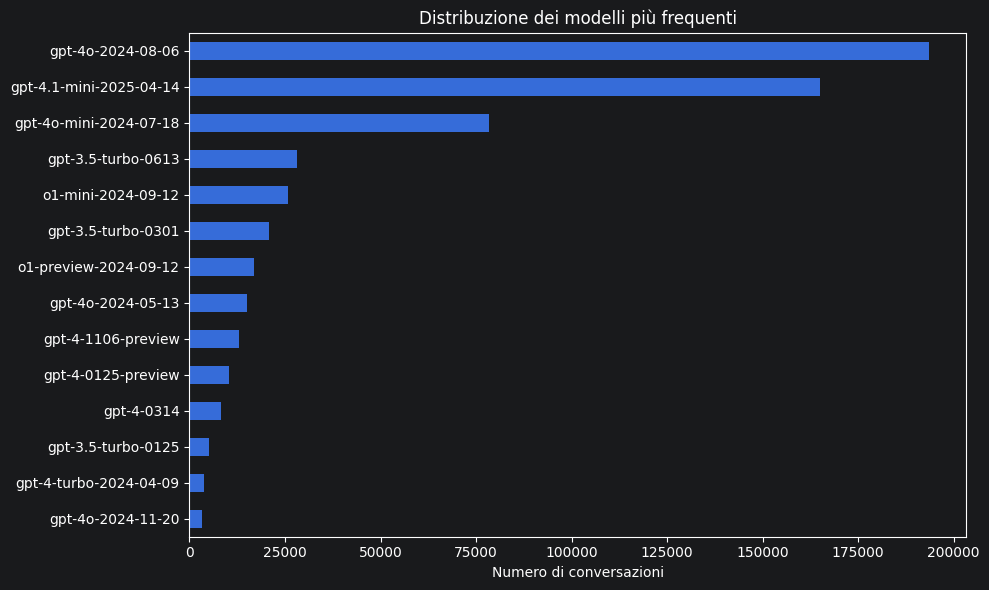

,value,count
0,gpt-4o-2024-08-06,193469
1,gpt-4.1-mini-2025-04-14,165119
2,gpt-4o-mini-2024-07-18,78287
3,gpt-3.5-turbo-0613,28198
4,o1-mini-2024-09-12,25759
5,gpt-3.5-turbo-0301,20698
6,o1-preview-2024-09-12,16940
7,gpt-4o-2024-05-13,15173
8,gpt-4-1106-preview,13035
9,gpt-4-0125-preview,10445


In [16]:
if "model" in meta_df.columns:
    model_distribution = plot_top_counts(
        meta_df["model"],
        title="Distribuzione dei modelli più frequenti",
        xlabel="Numero di conversazioni",
        top_n=25,
    )
    display(model_distribution)
else:
    print("La colonna model non è presente.")

### 4.2 Distribuzione dei turni

,turn
count,587568.000000
mean,1.899870
std,3.244051
min,1.000000
1%,1.000000
5%,1.000000
10%,1.000000
25%,1.000000
50%,1.000000
75%,1.000000


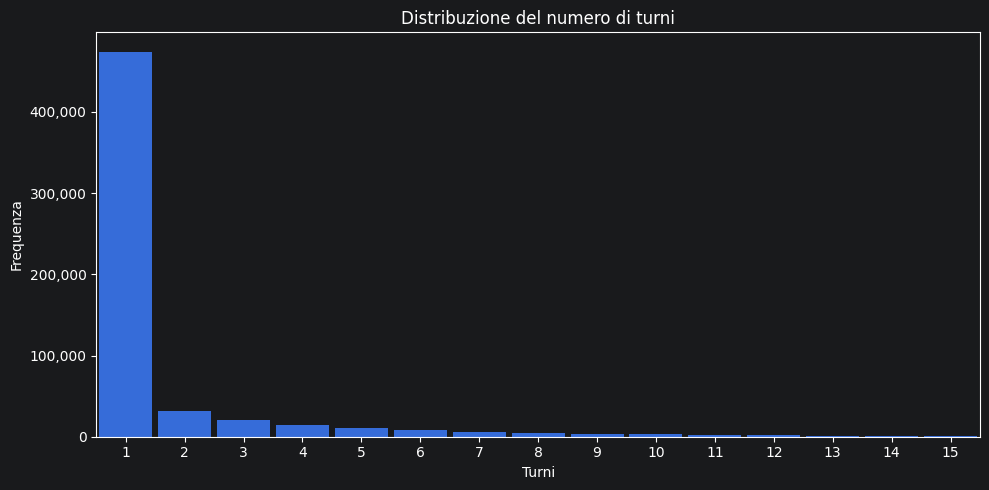

,turn,count
0,1,474368
1,2,31083
2,3,20574
3,4,14229
4,5,10159
5,6,7701
6,7,5931
7,8,4486
8,9,3628
9,10,2872


In [17]:
if "turn" in meta_df.columns:
    turn_summary = meta_df["turn"].describe(percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99])
    display(turn_summary.to_frame("turn"))

    # Limito la visualizzazione al 99° percentile e uso un bin per ogni valore intero di turn.
    # In questo modo il grafico resta leggibile senza aggregare più valori nello stesso bin.
    turn_values = meta_df["turn"].dropna().astype(int)
    turn_plot_upper_bound = max(1, int(np.ceil(turn_values.quantile(.99))))
    plot_values = turn_values.loc[turn_values <= turn_plot_upper_bound]
    bins = np.arange(plot_values.min() - 0.5, turn_plot_upper_bound + 1.5, 1)

    ax = plot_values.plot(kind="hist", bins=bins, figsize=(10, 5), rwidth=0.9)
    ax.set_title("Distribuzione del numero di turni")
    ax.set_xlabel("Turni")
    ax.set_ylabel("Frequenza")
    ax.set_xticks(range(int(plot_values.min()), turn_plot_upper_bound + 1))
    ax.set_xlim(plot_values.min() - 0.5, turn_plot_upper_bound + 0.5)
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    plt.tight_layout()
    plt.show()

    turn_distribution = (
        meta_df["turn"]
        .value_counts()
        .sort_index()
        .rename_axis("turn")
        .reset_index(name="count")
    )
    display(turn_distribution.head(50))
else:
    print("La colonna turn non è presente.")


### 4.3 Distribuzione delle lingue dichiarate nei messaggi

Uso la label `language` presente nei messaggi della conversazione.  
Questa distribuzione è più controllabile rispetto a una ricerca ricorsiva generica, perché per il filtro successivo mi interessa la lingua effettivamente associata a prompt e risposte.


In [18]:
def get_message_language(message: Any) -> str:
    """Leggo la label di lingua già presente nel messaggio, quando disponibile."""
    if isinstance(message, dict):
        language = message.get("language")
        return str(language).strip() if language is not None else ""
    return ""

language_counter = Counter()
role_language_counter = defaultdict(Counter)

for row in tqdm(full_ds, total=full_ds.num_rows, desc="Conteggio lingue dichiarate"):
    for message in flatten_conversation(row.get("conversation")):
        language = get_message_language(message)
        if language:
            language_counter[language] += 1
            role = get_message_role(message) or "role_missing"
            role_language_counter[role][language] += 1

language_distribution = (
    pd.DataFrame(language_counter.items(), columns=["language", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

display(language_distribution.head(50))

role_language_distribution = pd.DataFrame([
    {"role": role, "language": language, "count": count}
    for role, counter in role_language_counter.items()
    for language, count in counter.items()
]).sort_values(["role", "count"], ascending=[True, False]).reset_index(drop=True)

display(role_language_distribution.head(100))


Conteggio lingue dichiarate: 100%|██████████| 587568/587568 [00:51<00:00, 11497.95it/s]


,language,count
0,English,954676
1,Chinese,376905
2,Russian,316964
3,French,135855
4,Spanish,77032
5,Vietnamese,64552
6,Portuguese,47786
7,German,36095
8,Italian,28992
9,Arabic,27706


,role,language,count
0,assistant,English,449870
1,assistant,Chinese,201170
2,assistant,Russian,167242
3,assistant,Spanish,47737
4,assistant,French,37185
...,...,...,...
95,user,Sotho,2062
96,user,Japanese,1983
97,user,Esperanto,1929
98,user,Welsh,1695


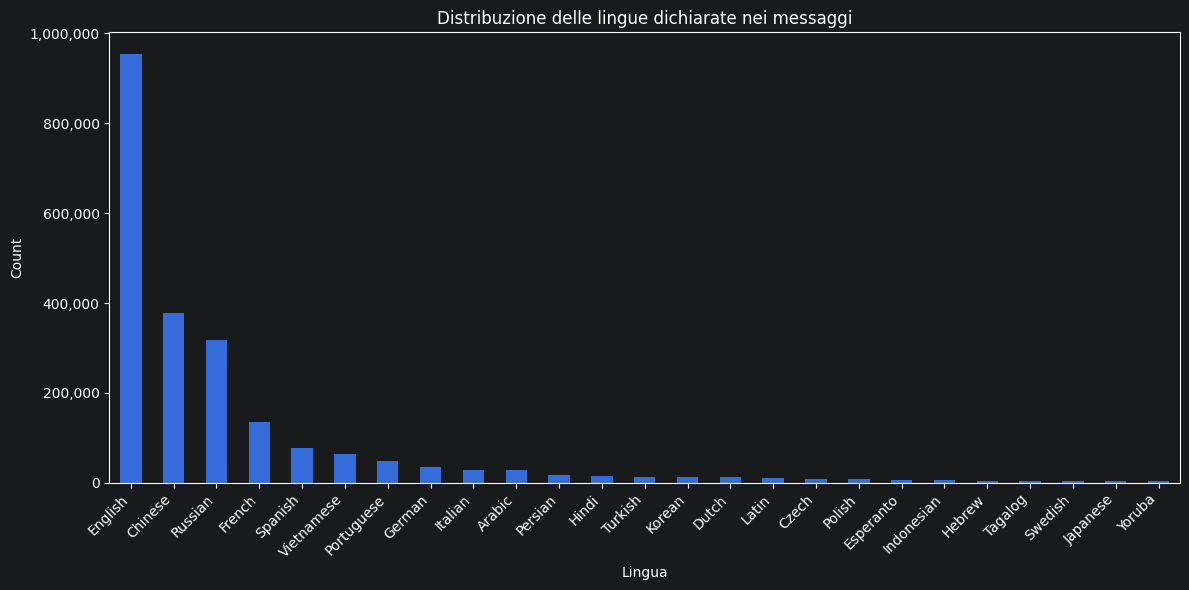

In [19]:
def plot_language_distribution(dist: pd.DataFrame, title: str, top_n: int = 25, figsize: tuple[int, int] = (12, 6), save_path: Path | None = None) -> None:
    """Visualizzo una distribuzione categoriale con lingua sull'asse x e conteggio assoluto sull'asse y."""
    plot_df = dist.head(top_n).copy()

    ax = plot_df.plot(
        x="language",
        y="count",
        kind="bar",
        legend=False,
        figsize=figsize,
    )
    ax.set_title(title)
    ax.set_xlabel("Lingua")
    ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

if not language_distribution.empty:
    plot_language_distribution(
        language_distribution,
        title="Distribuzione delle lingue dichiarate nei messaggi",
        top_n=25,
        save_path=FIGURES_DIR / "language_distribution_declared.png",
    )
else:
    print("Non ho trovato label di lingua nei messaggi della conversazione.")


## 5. Filtraggio progressivo del dataset

Da questa sezione in avanti costruisco una vista filtrata del dataset.  
Mantengo invariati i campi originali: ogni step rimuove solo record non coerenti con i criteri di analisi e salvo le dimensioni intermedie per rendere il processo tracciabile.


In [20]:

filtering_steps = []
filtered_ds = full_ds

def log_filtering_step(step_name: str, before: int, after: int, notes: str = "") -> None:
    filtering_steps.append({
        "step": step_name,
        "records_before": int(before),
        "records_after": int(after),
        "records_removed": int(before - after),
        "retention_pct_from_previous": round((after / before) * 100, 2) if before else np.nan,
        "retention_pct_from_original": round((after / full_ds.num_rows) * 100, 2) if full_ds.num_rows else np.nan,
        "notes": notes,
    })

def apply_dataset_filter(ds: Dataset, mask: list[bool], step_name: str, notes: str = "") -> Dataset:
    before = ds.num_rows
    kept_indices = [idx for idx, keep in enumerate(mask) if keep]
    out = ds.select(kept_indices)
    log_filtering_step(step_name, before, out.num_rows, notes)
    return out

def build_duplicate_records(ds: Dataset, key_func, key_name: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Costruisco una tabella ispezionabile dei gruppi duplicati per una chiave scelta."""
    records = []
    for idx, row in enumerate(tqdm(ds, total=ds.num_rows, desc=f"Valutazione duplicati: {key_name}")):
        key_value = key_func(row)
        records.append({
            "row_position": idx,
            "duplicate_key": key_value,
            "conversation_id": row.get("conversation_id"),
            "model": row.get("model"),
            "turn": row.get("turn"),
            "snippet_turns": row.get(snippet_turn_column),
            "first_user_prompt": get_first_user_prompt(row.get("conversation")),
        })

    records_df = pd.DataFrame(records)
    if records_df.empty:
        return records_df, records_df

    valid_key_mask = records_df["duplicate_key"].notna() & (records_df["duplicate_key"].astype(str).str.len() > 0)
    duplicate_mask = records_df["duplicate_key"].duplicated(keep=False) & valid_key_mask
    duplicate_records_df = records_df.loc[duplicate_mask].sort_values(["duplicate_key", "row_position"]).reset_index(drop=True)

    duplicate_groups_df = (
        duplicate_records_df.groupby("duplicate_key", dropna=False)
        .size()
        .reset_index(name="occurrences")
        .sort_values("occurrences", ascending=False)
        .reset_index(drop=True)
    )
    return duplicate_groups_df, duplicate_records_df

def deduplicate_dataset_by_key(ds: Dataset, key_func, step_name: str, notes: str = "") -> tuple[Dataset, pd.DataFrame]:
    """Rimuovo i duplicati mantenendo la prima occorrenza per chiavi non vuote."""
    before = ds.num_rows
    seen_keys = set()
    keep_indices = []
    removed_records = []

    for idx, row in enumerate(tqdm(ds, total=ds.num_rows, desc=step_name)):
        key_value = key_func(row)
        key_is_valid = key_value is not None and str(key_value).strip() != ""

        if key_is_valid and key_value in seen_keys:
            removed_records.append({
                "row_position_before_filter": idx,
                "duplicate_key": key_value,
                "conversation_id": row.get("conversation_id"),
                "model": row.get("model"),
                "turn": row.get("turn"),
                "snippet_turns": row.get(snippet_turn_column),
                "first_user_prompt_preview": get_first_user_prompt(row.get("conversation"))[:300],
            })
            continue

        keep_indices.append(idx)
        if key_is_valid:
            seen_keys.add(key_value)

    out = ds.select(keep_indices)
    log_filtering_step(step_name, before, out.num_rows, notes)
    return out, pd.DataFrame(removed_records)


In [21]:

# Deduplica iniziale: rimuovo subito record duplicati prima degli altri filtri.
# Mantengo sempre la prima occorrenza incontrata per ogni chiave non vuota.
pre_filter_id_duplicate_groups, pre_filter_id_duplicate_records = build_duplicate_records(
    filtered_ds,
    key_func=lambda row: row.get("conversation_id"),
    key_name="conversation_id_pre_filter",
)

print("Duplicati iniziali basati su conversation_id")
display(pre_filter_id_duplicate_groups.head(50))
display(pre_filter_id_duplicate_records.head(100))

filtered_ds, removed_duplicate_by_id_records_df = deduplicate_dataset_by_key(
    filtered_ds,
    key_func=lambda row: row.get("conversation_id"),
    step_name="Deduplica iniziale per conversation_id",
    notes="Mantengo la prima occorrenza per ogni conversation_id non vuoto prima degli altri filtri.",
)

pre_filter_first_prompt_duplicate_groups, pre_filter_first_prompt_duplicate_records = build_duplicate_records(
    filtered_ds,
    key_func=lambda row: stable_hash(get_first_user_prompt(row.get("conversation"))) if get_first_user_prompt(row.get("conversation")).strip() else "",
    key_name="hash_primo_prompt_utente_pre_filter",
)

print("Duplicati iniziali basati sul primo prompt utente, dopo deduplica per conversation_id")
display(pre_filter_first_prompt_duplicate_groups.head(50))
display(pre_filter_first_prompt_duplicate_records.head(100))

filtered_ds, removed_duplicate_by_first_prompt_records_df = deduplicate_dataset_by_key(
    filtered_ds,
    key_func=lambda row: stable_hash(get_first_user_prompt(row.get("conversation"))) if get_first_user_prompt(row.get("conversation")).strip() else "",
    step_name="Deduplica iniziale per primo prompt utente",
    notes="Mantengo la prima occorrenza per ogni primo prompt utente non vuoto, dopo la deduplica per conversation_id.",
)

pd.DataFrame(filtering_steps)


Valutazione duplicati: conversation_id_pre_filter: 100%|██████████| 587568/587568 [00:54<00:00, 10844.13it/s]


Duplicati iniziali basati su conversation_id


,duplicate_key,occurrences


,row_position,duplicate_key,conversation_id,model,turn,snippet_turns,first_user_prompt


Deduplica iniziale per conversation_id: 100%|██████████| 587568/587568 [00:56<00:00, 10384.28it/s]
Valutazione duplicati: hash_primo_prompt_utente_pre_filter: 100%|██████████| 587568/587568 [01:14<00:00, 7883.86it/s] 


Duplicati iniziali basati sul primo prompt utente, dopo deduplica per conversation_id


,duplicate_key,occurrences
0,b49177e05868b7af8e82a644c1ce20e521af46497adeaffe861d294d9b4bb75e,1470
1,adeedf73d6098a30d30b0f5f40c3ae4983bd475d0cadf315eb96fa8a53a7e819,587
2,5aa762ae383fbb727af3c7a36d4940a5b8c40a989452d2304fc958ff3f354e7a,530
3,3bb670b7c1b85462b262f6431125649bddf55c3941645e091a6330d613ff82e9,493
4,1a581f572189d5de0469e7ecb4867ab769111295f03a76d3b0bab399fc80467d,487
5,3b4f22b2ac60e7edc0d470d8a9aa32297ba1710eb476d6c3f13b7e676ea19456,458
6,d7bdaaab4e18e79603f106cb8f467319c50920031dba014de3e2e08c08e03865,439
7,fdda60cb3869b17ede5fda4d458c15689ed87c049e7b349ac86d5ebbcf882731,437
8,71ec428f3e2a3909fcdb1f78138694ad1b3dd609a4da6037fede44e64a0828a5,419
9,0922515335495b677fa44d53bcf0f33d9fbfc8fda4aba447afa805f0f206a8b9,397


,row_position,duplicate_key,conversation_id,model,turn,snippet_turns,first_user_prompt
0,255002,000060bcfd08d2ec28672f32d1cbd8524ace8c0f96873287d380ea501cddfbdf,bb0b1927dcd0763eed2f8bb2febe7379,gpt-4o-mini-2024-07-18,1,[1],"Goal :\n Générer une suggestion détaillée et visuellement attrayante pour la présentation finale d'un plat, basée sur le type, le titre, les ingrédients ..."
1,255008,000060bcfd08d2ec28672f32d1cbd8524ace8c0f96873287d380ea501cddfbdf,204ec72edbeb343009a2e6e9654cea94,gpt-4o-mini-2024-07-18,1,[1],"Goal :\n Générer une suggestion détaillée et visuellement attrayante pour la présentation finale d'un plat, basée sur le type, le titre, les ingrédients ..."
2,255019,000060bcfd08d2ec28672f32d1cbd8524ace8c0f96873287d380ea501cddfbdf,a586d60d4225a4945cfbfe99eeae9fc8,gpt-4o-mini-2024-07-18,1,[1],"Goal :\n Générer une suggestion détaillée et visuellement attrayante pour la présentation finale d'un plat, basée sur le type, le titre, les ingrédients ..."
3,42916,0001c240d09b506329644370b30117046fcc6b01d397298f4b145a78f3df0e37,3658c8d1014f1aad6e9a1b46895cb7b8,gpt-4o-2024-08-06,1,[1],Assistant: \nUser: ```\n标题：泰顺县图书馆公开招聘编外工作人员的公告\n因工作需要，经研究决定，县图书馆拟向社会公开招聘编外工作人员1名，现将有关事项公告如下:\n一、招聘原则\n坚持公开、平等、竞争、择优的原则。有较强抗压能力，执行能力。\n二、招聘条件\n(一)政治素质好，热爱祖国、...
4,42917,0001c240d09b506329644370b30117046fcc6b01d397298f4b145a78f3df0e37,54b854ae8b7b58606d956e013d010f38,gpt-4o-2024-08-06,1,[1],Assistant: \nUser: ```\n标题：泰顺县图书馆公开招聘编外工作人员的公告\n因工作需要，经研究决定，县图书馆拟向社会公开招聘编外工作人员1名，现将有关事项公告如下:\n一、招聘原则\n坚持公开、平等、竞争、择优的原则。有较强抗压能力，执行能力。\n二、招聘条件\n(一)政治素质好，热爱祖国、...
...,...,...,...,...,...,...,...
95,113988,00561d34bf1f941170697c8cd59b5a65260e8cb97118d2cb87a0e5481b4aeccf,ba7f945baf7f96588d75c53da684e829,gpt-4o-mini-2024-07-18,3,"[1, 2, 3]",crie uma logica em java script que cria uma variavel que assume o valor 'value' da chave 'access' do objeto abaixo:\nconst Informacoes = { \n id: '66425c...
96,260960,00566247b1aa883ec9ac0a165a67258d7e22f64562726e67b36665d53f972992,a497f620c81cf6b4583885543703093d,gpt-4-1106-preview,1,[1],"Переведи из matlab в python\nfunction mydiffusion(m,n_x,n_t)\n% Для запуска файла необходимо набрать в командном окне: >>\nmydiffusion(0,100,100)\nclose all..."
97,260962,00566247b1aa883ec9ac0a165a67258d7e22f64562726e67b36665d53f972992,10dc21b5a1ac73f878464c5a8da1d32e,gpt-4-1106-preview,2,"[1, 2]","Переведи из matlab в python\nfunction mydiffusion(m,n_x,n_t)\n% Для запуска файла необходимо набрать в командном окне: >>\nmydiffusion(0,100,100)\nclose all..."
98,260964,00566247b1aa883ec9ac0a165a67258d7e22f64562726e67b36665d53f972992,d7665c52a684c0e5a516d2386d3b77aa,gpt-4-1106-preview,1,[1],"Переведи из matlab в python\nfunction mydiffusion(m,n_x,n_t)\n% Для запуска файла необходимо набрать в командном окне: >>\nmydiffusion(0,100,100)\nclose all..."


Deduplica iniziale per primo prompt utente: 100%|██████████| 587568/587568 [01:14<00:00, 7905.18it/s] 


,step,records_before,records_after,records_removed,retention_pct_from_previous,retention_pct_from_original,notes
0,Deduplica iniziale per conversation_id,587568,587568,0,100.00,100.00,Mantengo la prima occorrenza per ogni conversation_id non vuoto prima degli altri filtri.
1,Deduplica iniziale per primo prompt utente,587568,516234,71334,87.86,87.86,"Mantengo la prima occorrenza per ogni primo prompt utente non vuoto, dopo la deduplica per conversation_id."


### 5.1 Rimozione delle conversazioni multi-turn

Per isolare l'effetto del primo prompt, mantengo solo le conversazioni con `turn == 1`.  
Questo criterio è coerente con l'idea di partire da interazioni semplici e confrontabili prima di introdurre dinamiche multi-turn.


In [22]:
before = filtered_ds.num_rows
single_turn_mask = [row["turn"] == 1 for row in tqdm(filtered_ds, total=filtered_ds.num_rows, desc="Filtro single-turn")]
filtered_ds = apply_dataset_filter(
    filtered_ds,
    single_turn_mask,
    step_name="Rimozione conversazioni multi-turn",
    notes="Mantengo solo record con turn == 1.",
)

pd.DataFrame(filtering_steps)


Filtro single-turn: 100%|██████████| 516234/516234 [00:55<00:00, 9265.04it/s] 


,step,records_before,records_after,records_removed,retention_pct_from_previous,retention_pct_from_original,notes
0,Deduplica iniziale per conversation_id,587568,587568,0,100.00,100.00,Mantengo la prima occorrenza per ogni conversation_id non vuoto prima degli altri filtri.
1,Deduplica iniziale per primo prompt utente,587568,516234,71334,87.86,87.86,"Mantengo la prima occorrenza per ogni primo prompt utente non vuoto, dopo la deduplica per conversation_id."
2,Rimozione conversazioni multi-turn,516234,413140,103094,80.03,70.31,Mantengo solo record con turn == 1.


### 5.2 Rimozione delle conversazioni senza snippet al primo turno

Mantengo solo le conversazioni in cui `snippet_turns` indica la presenza di snippet nel primo turno.  
Imposto esplicitamente l'indice del primo turno, così posso modificarlo facilmente se la documentazione del dataset conferma una convenzione diversa.


In [23]:
FIRST_TURN_INDEX = 1

def normalize_snippet_turns(value: Any) -> list[int]:
    if value is None:
        return []
    if isinstance(value, (int, np.integer)):
        return [int(value)]
    if isinstance(value, (list, tuple, set)):
        out = []
        for item in value:
            if item is None:
                continue
            try:
                out.append(int(item))
            except (TypeError, ValueError):
                pass
        return out
    return []

def has_snippet_at_first_turn(row: dict[str, Any]) -> bool:
    turns = normalize_snippet_turns(row.get(snippet_turn_column))
    return FIRST_TURN_INDEX in turns

snippet_first_turn_mask = [
    has_snippet_at_first_turn(row)
    for row in tqdm(filtered_ds, total=filtered_ds.num_rows, desc="Filtro snippet al primo turno")
]

filtered_ds = apply_dataset_filter(
    filtered_ds,
    snippet_first_turn_mask,
    step_name="Rimozione conversazioni senza snippet al primo turno",
    notes=f"Mantengo solo record in cui {snippet_turn_column} contiene {FIRST_TURN_INDEX}.",
)

pd.DataFrame(filtering_steps)


Filtro snippet al primo turno: 100%|██████████| 413140/413140 [00:38<00:00, 10862.96it/s]


,step,records_before,records_after,records_removed,retention_pct_from_previous,retention_pct_from_original,notes
0,Deduplica iniziale per conversation_id,587568,587568,0,100.00,100.00,Mantengo la prima occorrenza per ogni conversation_id non vuoto prima degli altri filtri.
1,Deduplica iniziale per primo prompt utente,587568,516234,71334,87.86,87.86,"Mantengo la prima occorrenza per ogni primo prompt utente non vuoto, dopo la deduplica per conversation_id."
2,Rimozione conversazioni multi-turn,516234,413140,103094,80.03,70.31,Mantengo solo record con turn == 1.
3,Rimozione conversazioni senza snippet al primo turno,413140,413140,0,100.00,70.31,Mantengo solo record in cui snippet_turns contiene 1.


### 5.3 Rimozione delle conversazioni con problemi strutturali

Rimuovo le conversazioni che non contengono almeno un messaggio utente non vuoto e almeno una risposta LLM non vuota.  
Questo intercetta casi come prompt utente senza risposta, risposta senza prompt, contenuti vuoti o conversazioni non interpretabili.


In [24]:
def conversation_quality_flags(conversation: Any) -> dict[str, Any]:
    messages = flatten_conversation(conversation)
    user_texts = [extract_text_from_message(message) for message in messages if is_user_message(message)]
    assistant_texts = [extract_text_from_message(message) for message in messages if is_assistant_message(message)]

    has_user_message = any(text.strip() for text in user_texts)
    has_assistant_message = any(text.strip() for text in assistant_texts)

    return {
        "n_messages": len(messages),
        "n_user_messages": len(user_texts),
        "n_assistant_messages": len(assistant_texts),
        "has_non_empty_user_message": has_user_message,
        "has_non_empty_assistant_message": has_assistant_message,
        "is_structurally_valid": len(messages) > 0 and has_user_message and has_assistant_message,
    }

problem_records = []
structural_valid_mask = []

for idx, row in enumerate(tqdm(filtered_ds, total=filtered_ds.num_rows, desc="Controllo problemi strutturali")):
    flags = conversation_quality_flags(row.get("conversation"))
    structural_valid_mask.append(flags["is_structurally_valid"])
    if not flags["is_structurally_valid"]:
        problem_records.append({
            "row_position_before_filter": idx,
            "conversation_id": row.get("conversation_id"),
            **flags,
            "first_user_prompt_preview": get_first_user_prompt(row.get("conversation"))[:300],
        })

problem_records_df = pd.DataFrame(problem_records)
display(problem_records_df.head(50))

filtered_ds = apply_dataset_filter(
    filtered_ds,
    structural_valid_mask,
    step_name="Rimozione conversazioni con problemi strutturali",
    notes="Mantengo solo conversazioni con almeno un prompt utente non vuoto e una risposta LLM non vuota.",
)

pd.DataFrame(filtering_steps)


Controllo problemi strutturali: 100%|██████████| 413140/413140 [00:42<00:00, 9699.00it/s] 


,row_position_before_filter,conversation_id,n_messages,n_user_messages,n_assistant_messages,has_non_empty_user_message,has_non_empty_assistant_message,is_structurally_valid,first_user_prompt_preview
0,17389,28cd56f16e1f09dacb15026cc4d472ac,2,1,1,False,True,False,
1,77863,cb763d16fce0e2e9ed9c87f972e7cce2,2,1,1,False,True,False,
2,94825,195f5d9789002b83eafa90fb9c99042c,2,1,1,False,True,False,
3,100036,fb43850da5afdd7731d1db36ea415202,2,1,1,False,True,False,
4,199428,f7394aee34093e8e8eb46a8d21d3ee7c,2,1,1,False,True,False,
5,203887,f91ce219c1bf4572cf81a0ec3ea8923e,2,1,1,False,True,False,
6,307465,c9e6f34cb1f2eb7c900052af3833c62a,2,1,1,False,True,False,
7,386087,5d0b3ced751dd70ae8a5428449f887fc,2,1,1,False,True,False,
8,388516,b87c1b8e86757fa7b8805a9d64793258,2,1,1,False,True,False,
9,388582,3ff013670042ae425d0c2ec95c4cb2d1,2,1,1,False,True,False,


,step,records_before,records_after,records_removed,retention_pct_from_previous,retention_pct_from_original,notes
0,Deduplica iniziale per conversation_id,587568,587568,0,100.00,100.00,Mantengo la prima occorrenza per ogni conversation_id non vuoto prima degli altri filtri.
1,Deduplica iniziale per primo prompt utente,587568,516234,71334,87.86,87.86,"Mantengo la prima occorrenza per ogni primo prompt utente non vuoto, dopo la deduplica per conversation_id."
2,Rimozione conversazioni multi-turn,516234,413140,103094,80.03,70.31,Mantengo solo record con turn == 1.
3,Rimozione conversazioni senza snippet al primo turno,413140,413140,0,100.00,70.31,Mantengo solo record in cui snippet_turns contiene 1.
4,Rimozione conversazioni con problemi strutturali,413140,413129,11,100.00,70.31,Mantengo solo conversazioni con almeno un prompt utente non vuoto e una risposta LLM non vuota.


### 5.4 Rimozione delle conversazioni non completamente inglesi

Uso prima la label `language` presente nei messaggi, perché è il metadato nativo del dataset.  
Aggiungo poi un controllo con `langdetect` sul testo ripulito dai blocchi di codice, così posso intercettare casi in cui una conversazione viene etichettata come inglese solo perché contiene codice o token tecnici.


In [25]:

ENGLISH_LABELS = {"en", "eng", "english"}
MIN_ALPHA_CHARS_FOR_LANGDETECT = 40

CODE_BLOCK_RE = re.compile(r"```.*?```", flags=re.DOTALL)
INLINE_CODE_RE = re.compile(r"`[^`]*`")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
NON_TEXT_RE = re.compile(r"[^A-Za-zÀ-ÖØ-öø-ÿ\s]")

def normalize_language_label(label: str) -> str:
    return str(label).strip().lower().replace("_", "-")

def is_english_label(label: str) -> bool:
    normalized = normalize_language_label(label)
    return normalized in ENGLISH_LABELS or normalized.startswith("en-")

def strip_code_for_language_detection(text: str) -> str:
    text = CODE_BLOCK_RE.sub(" ", text or "")
    text = INLINE_CODE_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = NON_TEXT_RE.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def detect_language_safely(text: str) -> dict[str, Any]:
    cleaned = strip_code_for_language_detection(text)
    alpha_chars = sum(ch.isalpha() for ch in cleaned)

    if not LANGDETECT_AVAILABLE:
        return {
            "langdetect": "langdetect_not_installed",
            "cleaned_text": cleaned,
            "alpha_chars": alpha_chars,
        }

    if alpha_chars < MIN_ALPHA_CHARS_FOR_LANGDETECT:
        return {
            "langdetect": "not_enough_text",
            "cleaned_text": cleaned,
            "alpha_chars": alpha_chars,
        }

    try:
        detected = detect(cleaned)
    except LangDetectException:
        detected = "detection_error"

    return {
        "langdetect": detected,
        "cleaned_text": cleaned,
        "alpha_chars": alpha_chars,
    }

def conversation_language_label_flags(conversation: Any) -> dict[str, Any]:
    """Controllo prima le label language già presenti nel dataset."""
    messages = flatten_conversation(conversation)
    checked_messages = []
    label_failures = []

    for position, message in enumerate(messages):
        text = extract_text_from_message(message)
        if not text.strip():
            continue

        role = get_message_role(message) or "role_missing"
        label = get_message_language(message)
        label_is_english = is_english_label(label)

        checked_messages.append({
            "position": position,
            "role": role,
            "label": label,
            "label_is_english": label_is_english,
            "preview": text[:250],
        })

        if not label_is_english:
            label_failures.append(checked_messages[-1])

    return {
        "n_checked_messages": len(checked_messages),
        "all_labels_english": len(checked_messages) > 0 and len(label_failures) == 0,
        "label_failures": label_failures,
    }

def conversation_langdetect_flags(conversation: Any) -> dict[str, Any]:
    """Applico langdetect solo al subset che ha già superato il filtro sulle label."""
    messages = flatten_conversation(conversation)
    checked_messages = []
    detect_failures = []
    short_user_prompts = []

    for position, message in enumerate(messages):
        text = extract_text_from_message(message)
        if not text.strip():
            continue

        role = get_message_role(message) or "role_missing"
        label = get_message_language(message)
        detection = detect_language_safely(text)
        detected = detection["langdetect"]
        detect_is_english = detected in {"en", "not_enough_text", "langdetect_not_installed"}

        checked_message = {
            "position": position,
            "role": role,
            "label": label,
            "langdetect": detected,
            "alpha_chars_after_cleaning": detection["alpha_chars"],
            "langdetect_is_compatible": detect_is_english,
            "preview": text[:250],
            "cleaned_preview": detection["cleaned_text"][:250],
        }
        checked_messages.append(checked_message)

        if detected == "not_enough_text" and is_user_message(message):
            short_user_prompts.append(checked_message)

        if not detect_is_english:
            detect_failures.append(checked_message)

    return {
        "n_checked_messages": len(checked_messages),
        "all_langdetect_compatible": len(checked_messages) > 0 and len(detect_failures) == 0,
        "langdetect_failures": detect_failures,
        "short_user_prompts": short_user_prompts,
    }

# 1) Rimuovo prima tutte le conversazioni in cui almeno un messaggio non vuoto ha label language diversa da inglese.
label_problem_records = []
label_english_mask = []

for idx, row in enumerate(tqdm(filtered_ds, total=filtered_ds.num_rows, desc="Filtro label language inglese")):
    flags = conversation_language_label_flags(row.get("conversation"))
    label_english_mask.append(flags["all_labels_english"])
    if not flags["all_labels_english"]:
        label_problem_records.append({
            "row_position_before_filter": idx,
            "conversation_id": row.get("conversation_id"),
            "n_checked_messages": flags["n_checked_messages"],
            "all_labels_english": flags["all_labels_english"],
            "label_failures": flags["label_failures"],
            "first_user_prompt_preview": get_first_user_prompt(row.get("conversation"))[:300],
        })

label_problem_records_df = pd.DataFrame(label_problem_records)
display(label_problem_records_df.head(50))

filtered_ds = apply_dataset_filter(
    filtered_ds,
    label_english_mask,
    step_name="Rimozione conversazioni con label language non inglese",
    notes="Mantengo solo conversazioni in cui tutti i messaggi non vuoti hanno una label language inglese.",
)

# 2) Sul subset rimasto applico un controllo aggiuntivo con langdetect dopo aver rimosso codice, inline code e URL.
langdetect_problem_records = []
langdetect_short_prompt_records = []
langdetect_english_mask = []

for idx, row in enumerate(tqdm(filtered_ds, total=filtered_ds.num_rows, desc="Controllo langdetect sul subset inglese")):
    flags = conversation_langdetect_flags(row.get("conversation"))
    langdetect_english_mask.append(flags["all_langdetect_compatible"])

    if flags["all_langdetect_compatible"] and flags["short_user_prompts"]:
        for short_prompt in flags["short_user_prompts"]:
            langdetect_short_prompt_records.append({
                "row_position_after_label_filter": idx,
                "conversation_id": row.get("conversation_id"),
                "message_position": short_prompt["position"],
                "role": short_prompt["role"],
                "label": short_prompt["label"],
                "langdetect": short_prompt["langdetect"],
                "alpha_chars_after_cleaning": short_prompt["alpha_chars_after_cleaning"],
                "prompt_preview": short_prompt["preview"],
                "cleaned_prompt_preview": short_prompt["cleaned_preview"],
                "first_user_prompt_preview": get_first_user_prompt(row.get("conversation"))[:300],
            })

    if not flags["all_langdetect_compatible"]:
        langdetect_problem_records.append({
            "row_position_after_label_filter": idx,
            "conversation_id": row.get("conversation_id"),
            "n_checked_messages": flags["n_checked_messages"],
            "all_langdetect_compatible": flags["all_langdetect_compatible"],
            "langdetect_failures": flags["langdetect_failures"],
            "first_user_prompt_preview": get_first_user_prompt(row.get("conversation"))[:300],
        })

langdetect_problem_records_df = pd.DataFrame(langdetect_problem_records)
langdetect_short_prompt_records_df = pd.DataFrame(langdetect_short_prompt_records)

display(langdetect_problem_records_df.head(50))
print("Prompt utente troppo corti che hanno passato il controllo langdetect")
display(langdetect_short_prompt_records_df.head(50))

filtered_ds = apply_dataset_filter(
    filtered_ds,
    langdetect_english_mask,
    step_name="Rimozione conversazioni non confermate da langdetect",
    notes="Sul subset con label inglese mantengo solo conversazioni in cui langdetect è compatibile con inglese per tutti i messaggi non vuoti. I prompt utente troppo corti vengono loggati ma non rimossi automaticamente.",
)

pd.DataFrame(filtering_steps)


Filtro label language inglese: 100%|██████████| 413129/413129 [00:43<00:00, 9469.55it/s] 


,row_position_before_filter,conversation_id,n_checked_messages,all_labels_english,label_failures,first_user_prompt_preview
0,2,a53c32dad716ca5cacde9dbf35dd0ad1,2,False,"[{'position': 0, 'role': 'user', 'label': 'Chinese', 'label_is_english': False, 'preview': '在backtrader的自定义策略的next 方法里，用plt.plot(['2021-06-10', '2021-06-16'...","在backtrader的自定义策略的next 方法里，用plt.plot(['2021-06-10', '2021-06-16'], [225, 355], linestyle='-', linewidth=1, color='g', alpha=0.8, picker=5)\n画了一条连接两个点的直线，但会生..."
1,3,49d5eb7c804f3493c94c578423697d83,2,False,"[{'position': 0, 'role': 'user', 'label': 'Russian', 'label_is_english': False, 'preview': 'Написать SDI-приложение Windows, заголовок главного окна, которо...","Написать SDI-приложение Windows, заголовок главного окна, которого\nсодержит ФИО, группу и номер варианта - QT-GI-15.\nПриложение должно выполнять анимацию ..."
2,4,a52b628b634b185d78f2e10cd5e5efcd,2,False,"[{'position': 1, 'role': 'assistant', 'label': 'Russian', 'label_is_english': False, 'preview': 'Да, можно заменить ios::binary на ios::out, так как это реж...","Можно ли заменить ios::binary и сделать более простым код? // Function to save data from an array of cars into a file\nvoid save_data(Car* cars, int n) {\no..."
3,5,eb0f7d36519bb672f95bab7774fdba55,2,False,"[{'position': 0, 'role': 'user', 'label': 'Chinese', 'label_is_english': False, 'preview': 'QFontMetrics计算带字间距的文本宽度'}, {'position': 1, 'role': 'assistant', ...",QFontMetrics计算带字间距的文本宽度
4,9,af2a27eda4911974458a45ab54c630b7,2,False,"[{'position': 0, 'role': 'user', 'label': 'Latin', 'label_is_english': False, 'preview': 'make a python program to crawle the p rate of this website: 'https...",make a python program to crawle the p rate of this website: 'https://www.ocbcwhhk.com/whb/action/rate/whbRate.do?id=prime_lending_rate&locale=en-us'
5,10,80f028375217dbdc4962ddb4d3e0f371,2,False,"[{'position': 0, 'role': 'user', 'label': 'Chinese', 'label_is_english': False, 'preview': '怎样用navicat链接MongoDB'}, {'position': 1, 'role': 'assistant', 'lab...",怎样用navicat链接MongoDB
6,11,1e12cc8ed89fd473b8cad404fb1d7a4b,2,False,"[{'position': 0, 'role': 'user', 'label': 'German', 'label_is_english': False, 'preview': 'Kannst du mir eine C#-Methode schreiben, die mir effizient das we...","Kannst du mir eine C#-Methode schreiben, die mir effizient das weiteste Datum zurück gibt, basierend auf einem Startdatum, einem Set an Wochentagen und der ..."
7,13,153c10190a7e59fb7a26b6d90a265845,2,False,"[{'position': 0, 'role': 'user', 'label': 'Chinese', 'label_is_english': False, 'preview': 'weak_ptr<子类> = weak_ptr<基类>，如何使得这个赋值成立'}]",weak_ptr<子类> = weak_ptr<基类>，如何使得这个赋值成立
8,14,2295d99dad7764e873ffd60bfc606f93,2,False,"[{'position': 0, 'role': 'user', 'label': 'Chinese', 'label_is_english': False, 'preview': 'python中如何遍历一个类的属性'}, {'position': 1, 'role': 'assistant', 'label...",python中如何遍历一个类的属性
9,16,c309e0ea828e17bf0c37bcc9f992b0d1,2,False,"[{'position': 0, 'role': 'user', 'label': 'Chinese', 'label_is_english': False, 'preview': '使用java parser时，如何遍历compilation unit的节点，且可以修改其中的node'}, {'positio...",使用java parser时，如何遍历compilation unit的节点，且可以修改其中的node


Controllo langdetect sul subset inglese: 100%|██████████| 102927/102927 [15:28<00:00, 110.84it/s]


,row_position_after_label_filter,conversation_id,n_checked_messages,all_langdetect_compatible,langdetect_failures,first_user_prompt_preview
0,38,ad7fca510531aad2cb61a340e88f391f,2,False,"[{'position': 0, 'role': 'user', 'label': 'English', 'langdetect': 'ca', 'alpha_chars_after_cleaning': 255, 'langdetect_is_compatible': False, 'preview': 'v...","void fn(int seq, int sub) {\n final SEQ_LENGTH = seq;\n final SUB_LENGTH = sub;\n\n final s = List.generate(\n SEQ_LENGTH, (index) => index); // seq..."
1,82,8b867dcd14f0a56761070d4767db8c5a,2,False,"[{'position': 0, 'role': 'user', 'label': 'English', 'langdetect': 'fr', 'alpha_chars_after_cleaning': 48, 'langdetect_is_compatible': False, 'preview': 'La...",Laravel storage s3. How to get multiple files in one request?
2,167,51563fb707200d1c4b35b76e172979b7,2,False,"[{'position': 0, 'role': 'user', 'label': 'English', 'langdetect': 'it', 'alpha_chars_after_cleaning': 364, 'langdetect_is_compatible': False, 'preview': 'W...","Write python program for this:\n\nExample 1\n\nInput string:\n\ndo do decl tirele is{ 'bigeso' .'esla' }. done, do decl investment_937 is\n{ 'bevela' . 'rel..."
3,232,80304b0b8a90f631f84ab25a79140184,2,False,"[{'position': 0, 'role': 'user', 'label': 'English', 'langdetect': 'fr', 'alpha_chars_after_cleaning': 45, 'langdetect_is_compatible': False, 'preview': 'vo...","void fun(int n) \n{ \n if (n == 0) \n return; \n printf(""%d"", n%2); \n fun(n/2); \n} if n= 25 give output"
4,1233,e4e30f24d1ecd67d1c2c30482ce0df54,2,False,"[{'position': 1, 'role': 'assistant', 'label': 'English', 'langdetect': 'no', 'alpha_chars_after_cleaning': 65, 'langdetect_is_compatible': False, 'preview'...",package com.example.myapplication.api;\n\nimport android.os.AsyncTask;\nimport android.util.Log;\n\nimport com.example.myapplication.CurrencyRate;\nimport c...
5,1256,5cf623f27214ae37a1c6a0347fdc7c5a,2,False,"[{'position': 1, 'role': 'assistant', 'label': 'English', 'langdetect': 'fr', 'alpha_chars_after_cleaning': 605, 'langdetect_is_compatible': False, 'preview...","CREATE DATABASE hotel;\nUSE hotel;\n\n-- Таблица Guests (Гости)\nCREATE TABLE Guests (\nguest_id INT AUTO_INCREMENT PRIMARY KEY,\nname VARCHAR(100) NOT NULL..."
6,1268,5bfd34f6c184d613bf8d300ea7adc281,2,False,"[{'position': 1, 'role': 'assistant', 'label': 'English', 'langdetect': 'da', 'alpha_chars_after_cleaning': 58, 'langdetect_is_compatible': False, 'preview'...",این کد دسترسی به کلیپ بورد رو محدود کرده درست کن <p>&nbsp;</p>\n<style>\n body {\n margin: 0;\n padding: 0;\n overflow: hidden;\n ...
7,1304,9cbee8e17614cfc8d35b739fbfd45956,2,False,"[{'position': 0, 'role': 'user', 'label': 'English', 'langdetect': 'fr', 'alpha_chars_after_cleaning': 659, 'langdetect_is_compatible': False, 'preview': 'U...","User: привет\nAssistant: Привет! Как я могу помочь вам сегодня?\nUser: Перепиши используя прокси в запросах. import requests\nimport json\n\nurl = ""https://..."
8,1313,06e00e5305a4c1f5d519e36d4e69a23a,2,False,"[{'position': 1, 'role': 'assistant', 'label': 'English', 'langdetect': 'af', 'alpha_chars_after_cleaning': 169, 'langdetect_is_compatible': False, 'preview...",hotel-backend/\n├── config/\n│ └── config.js\n├── controllers/\n│ ├── authController.js\n│ ├── guestController.js\n│ ├── paymentController.js\n│ ├...
9,1320,5cb37e067e420a7b0308f4cf16adb880,2,False,"[{'position': 0, 'role': 'user', 'label': 'English', 'langdetect': 'nl', 'alpha_chars_after_cleaning': 54, 'langdetect_is_compatible': False, 'preview': 'su...",sudo -H gedit /etc/fstab ...


Prompt utente troppo corti che hanno passato il controllo langdetect


,row_position_after_label_filter,conversation_id,message_position,role,label,langdetect,alpha_chars_after_cleaning,prompt_preview,cleaned_prompt_preview,first_user_prompt_preview
0,28,8fb0c982e210dd866292b698a64a516f,0,user,English,not_enough_text,39,laravel 10. how to setup custom s3 storage and use it?,laravel how to setup custom s storage and use it,laravel 10. how to setup custom s3 storage and use it?
1,46,867c53fd088b41e072883694ce0738d2,0,user,English,not_enough_text,24,How to log a &[u8] to string in Rust,How to log a u to string in Rust,How to log a &[u8] to string in Rust
2,52,3e1894d48e9691ed5d48fa674a48b1f7,0,user,English,not_enough_text,15,How to use enum in c++?,How to use enum in c,How to use enum in c++?
3,69,0e7acc4224275c028dfe35a77ecd0d1e,0,user,English,not_enough_text,33,I want to update python from 3.9 to 3.10 in centos.,I want to update python from to in centos,I want to update python from 3.9 to 3.10 in centos.
4,73,17d144165363e275e02494fc0d722105,0,user,English,not_enough_text,12,"分析并优化如下代码，使其文字区域的高度一直，要有title，并保证文字要对齐\n\nHTML:\n\n```\n<div class=""card-list"">\n <div class=""card-item"">\n <div class=""card-img"">\n <img src=""//se...",title HTML CSS,"分析并优化如下代码，使其文字区域的高度一直，要有title，并保证文字要对齐\n\nHTML:\n\n```\n<div class=""card-list"">\n <div class=""card-item"">\n <div class=""card-img"">\n <img src=""//se..."
5,80,978db8bd40084e27b3a6eee7ca235f2a,0,user,English,not_enough_text,15,teach me count SQL,teach me count SQL,teach me count SQL
6,83,3a2be6c55fea44af86c875973a18b39a,0,user,English,not_enough_text,25,Laravel s3 delete all files how?,Laravel s delete all files how,Laravel s3 delete all files how?
7,85,10be6ac61c2884e18a9ffaafbe33e237,0,user,English,not_enough_text,24,how to pause 5 secondon python,how to pause secondon python,how to pause 5 secondon python
8,90,df5238a3fbc21fba131059a0bf224cfe,0,user,English,not_enough_text,27,Make for me a game pong on scratch,Make for me a game pong on scratch,Make for me a game pong on scratch
9,92,877eacbb86216cb56307d574f3b4be52,0,user,English,not_enough_text,31,write code ball game c++ use glut open gl,write code ball game c use glut open gl,write code ball game c++ use glut open gl


,step,records_before,records_after,records_removed,retention_pct_from_previous,retention_pct_from_original,notes
0,Deduplica iniziale per conversation_id,587568,587568,0,100.00,100.00,Mantengo la prima occorrenza per ogni conversation_id non vuoto prima degli altri filtri.
1,Deduplica iniziale per primo prompt utente,587568,516234,71334,87.86,87.86,"Mantengo la prima occorrenza per ogni primo prompt utente non vuoto, dopo la deduplica per conversation_id."
2,Rimozione conversazioni multi-turn,516234,413140,103094,80.03,70.31,Mantengo solo record con turn == 1.
3,Rimozione conversazioni senza snippet al primo turno,413140,413140,0,100.00,70.31,Mantengo solo record in cui snippet_turns contiene 1.
4,Rimozione conversazioni con problemi strutturali,413140,413129,11,100.00,70.31,Mantengo solo conversazioni con almeno un prompt utente non vuoto e una risposta LLM non vuota.
5,Rimozione conversazioni con label language non inglese,413129,102927,310202,24.91,17.52,Mantengo solo conversazioni in cui tutti i messaggi non vuoti hanno una label language inglese.
6,Rimozione conversazioni non confermate da langdetect,102927,101190,1737,98.31,17.22,Sul subset con label inglese mantengo solo conversazioni in cui langdetect è compatibile con inglese per tutti i messaggi non vuoti. I prompt utente troppo ...


## 6. Valutazione dei duplicati nel dataset filtrato

A questo punto non rimuovo automaticamente i duplicati: li quantifico e stampo i record interessati.  
Valuto sia i duplicati basati su `conversation_id`, sia quelli basati sul contenuto, con attenzione al primo messaggio dell'utente.


In [26]:

post_filter_id_duplicate_groups, post_filter_id_duplicate_records = build_duplicate_records(
    filtered_ds,
    key_func=lambda row: row.get("conversation_id"),
    key_name="conversation_id_post_filter",
)

post_filter_first_prompt_duplicate_groups, post_filter_first_prompt_duplicate_records = build_duplicate_records(
    filtered_ds,
    key_func=lambda row: stable_hash(get_first_user_prompt(row.get("conversation"))) if get_first_user_prompt(row.get("conversation")).strip() else "",
    key_name="hash_primo_prompt_utente_post_filter",
)

print("Duplicati residui basati su conversation_id")
display(post_filter_id_duplicate_groups.head(50))
display(post_filter_id_duplicate_records.head(100))

print("Duplicati residui basati sul primo prompt utente")
display(post_filter_first_prompt_duplicate_groups.head(50))
display(post_filter_first_prompt_duplicate_records.head(100))


Valutazione duplicati: conversation_id_post_filter: 100%|██████████| 101190/101190 [00:10<00:00, 10054.04it/s]
Valutazione duplicati: hash_primo_prompt_utente_post_filter: 100%|██████████| 101190/101190 [00:14<00:00, 6799.94it/s]


Duplicati residui basati su conversation_id


,duplicate_key,occurrences


,row_position,duplicate_key,conversation_id,model,turn,snippet_turns,first_user_prompt


Duplicati residui basati sul primo prompt utente


,duplicate_key,occurrences


,row_position,duplicate_key,conversation_id,model,turn,snippet_turns,first_user_prompt


## 7. Dimensioni finali e salvataggio degli output principali

Salvo le dimensioni intermedie, il dataset filtrato, le tabelle di controllo e i grafici necessari.  
Questi file rendono riproducibile la selezione dei dati e mi permettono di proseguire con un notebook successivo dedicato alle metriche sui prompt e al technical debt.


In [28]:

filtering_steps_df = pd.DataFrame(filtering_steps)
display(filtering_steps_df)

filtered_meta_df = filtered_ds.select_columns([col for col in ["conversation_id", "model", "turn"] if col in filtered_ds.column_names]).to_pandas()

filtered_size_summary = pd.DataFrame({
    "metric": [
        "original_records",
        "filtered_records",
        "removed_records",
        "retention_pct",
        "n_columns",
        "n_models_filtered",
    ],
    "value": [
        full_ds.num_rows,
        filtered_ds.num_rows,
        full_ds.num_rows - filtered_ds.num_rows,
        round((filtered_ds.num_rows / full_ds.num_rows) * 100, 2) if full_ds.num_rows else np.nan,
        filtered_ds.num_columns,
        filtered_meta_df["model"].nunique(dropna=True) if "model" in filtered_meta_df.columns else np.nan,
    ],
})

display(filtered_size_summary)

# Salvo tabelle principali.
filtering_steps_df.to_csv(TABLES_DIR / "filtering_steps_summary.csv", index=False)
filtered_size_summary.to_csv(TABLES_DIR / "filtered_dataset_size_summary.csv", index=False)

removed_duplicate_by_id_records_df.to_csv(
    TABLES_DIR / "removed_duplicate_records_by_id.csv",
    index=False,
)
removed_duplicate_by_first_prompt_records_df.to_csv(
    TABLES_DIR / "removed_duplicate_records_by_first_user_prompt.csv",
    index=False,
)
pre_filter_id_duplicate_groups.to_csv(TABLES_DIR / "pre_filter_duplicate_groups_by_id.csv", index=False)
pre_filter_id_duplicate_records.to_csv(TABLES_DIR / "pre_filter_duplicate_records_by_id.csv", index=False)
pre_filter_first_prompt_duplicate_groups.to_csv(TABLES_DIR / "pre_filter_duplicate_groups_by_first_user_prompt.csv", index=False)
pre_filter_first_prompt_duplicate_records.to_csv(TABLES_DIR / "pre_filter_duplicate_records_by_first_user_prompt.csv", index=False)

problem_records_df.to_csv(TABLES_DIR / "removed_structural_problem_records.csv", index=False)
label_problem_records_df.to_csv(
    TABLES_DIR / "removed_non_english_by_language_label_records.csv",
    index=False,
)
langdetect_problem_records_df.to_csv(
    TABLES_DIR / "removed_non_english_by_langdetect_records.csv",
    index=False,
)
langdetect_short_prompt_records_df.to_csv(
    TABLES_DIR / "langdetect_short_user_prompts_passed.csv",
    index=False,
)

post_filter_id_duplicate_groups.to_csv(TABLES_DIR / "post_filter_duplicate_groups_by_id.csv", index=False)
post_filter_id_duplicate_records.to_csv(TABLES_DIR / "post_filter_duplicate_records_by_id.csv", index=False)
post_filter_first_prompt_duplicate_groups.to_csv(TABLES_DIR / "post_filter_duplicate_groups_by_first_user_prompt.csv", index=False)
post_filter_first_prompt_duplicate_records.to_csv(TABLES_DIR / "post_filter_duplicate_records_by_first_user_prompt.csv", index=False)

# Salvo il dataset filtrato in quattro formati: Hugging Face Dataset, Parquet, JSON e JSONL.
filtered_ds.save_to_disk(str(DATA_DIR / "codechat_v2_filtered_dataset"))
filtered_ds.to_parquet(str(DATA_DIR / "codechat_v2_filtered_dataset.parquet"))
filtered_ds.to_json(str(DATA_DIR / "codechat_v2_filtered_dataset.jsonl"), orient="records", lines=True, force_ascii=False)

print(f"Dataset filtrato salvato in: {DATA_DIR / 'codechat_v2_filtered_dataset'}")
print(f"Parquet salvato in: {DATA_DIR / 'codechat_v2_filtered_dataset.parquet'}")
print(f"JSONL salvato in: {DATA_DIR / 'codechat_v2_filtered_dataset.jsonl'}")


,step,records_before,records_after,records_removed,retention_pct_from_previous,retention_pct_from_original,notes
0,Deduplica iniziale per conversation_id,587568,587568,0,100.00,100.00,Mantengo la prima occorrenza per ogni conversation_id non vuoto prima degli altri filtri.
1,Deduplica iniziale per primo prompt utente,587568,516234,71334,87.86,87.86,"Mantengo la prima occorrenza per ogni primo prompt utente non vuoto, dopo la deduplica per conversation_id."
2,Rimozione conversazioni multi-turn,516234,413140,103094,80.03,70.31,Mantengo solo record con turn == 1.
3,Rimozione conversazioni senza snippet al primo turno,413140,413140,0,100.00,70.31,Mantengo solo record in cui snippet_turns contiene 1.
4,Rimozione conversazioni con problemi strutturali,413140,413129,11,100.00,70.31,Mantengo solo conversazioni con almeno un prompt utente non vuoto e una risposta LLM non vuota.
5,Rimozione conversazioni con label language non inglese,413129,102927,310202,24.91,17.52,Mantengo solo conversazioni in cui tutti i messaggi non vuoti hanno una label language inglese.
6,Rimozione conversazioni non confermate da langdetect,102927,101190,1737,98.31,17.22,Sul subset con label inglese mantengo solo conversazioni in cui langdetect è compatibile con inglese per tutti i messaggi non vuoti. I prompt utente troppo ...


,metric,value
0,original_records,587568.00
1,filtered_records,101190.00
2,removed_records,486378.00
3,retention_pct,17.22
4,n_columns,5.00
5,n_models_filtered,14.00


Creating json from Arrow format: 100%|██████████| 102/102 [00:16<00:00,  6.02ba/s]

Dataset filtrato salvato in: outputs\data\codechat_v2_filtered_dataset
Parquet salvato in: outputs\data\codechat_v2_filtered_dataset.parquet
JSONL salvato in: outputs\data\codechat_v2_filtered_dataset.jsonl


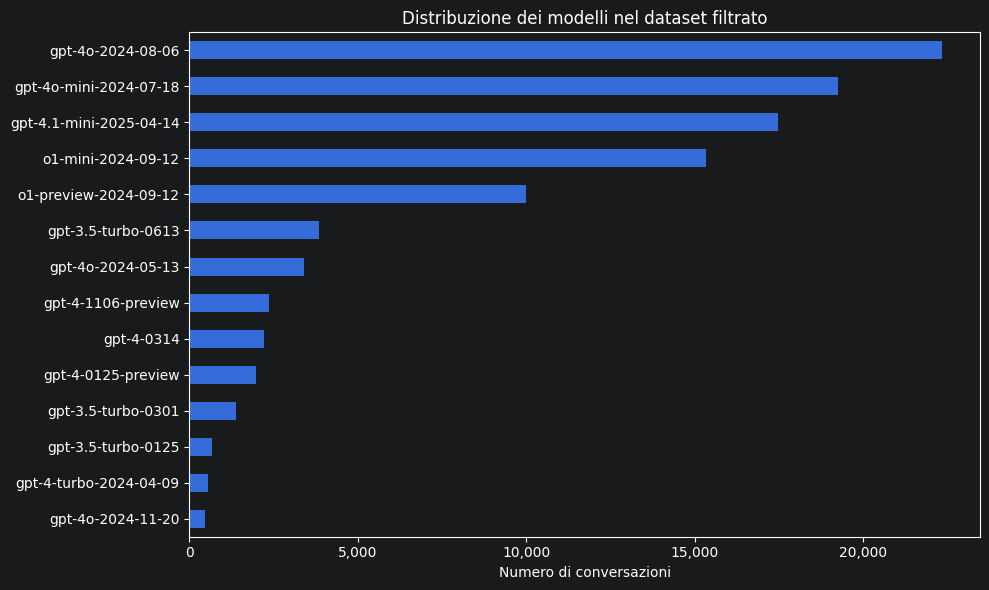

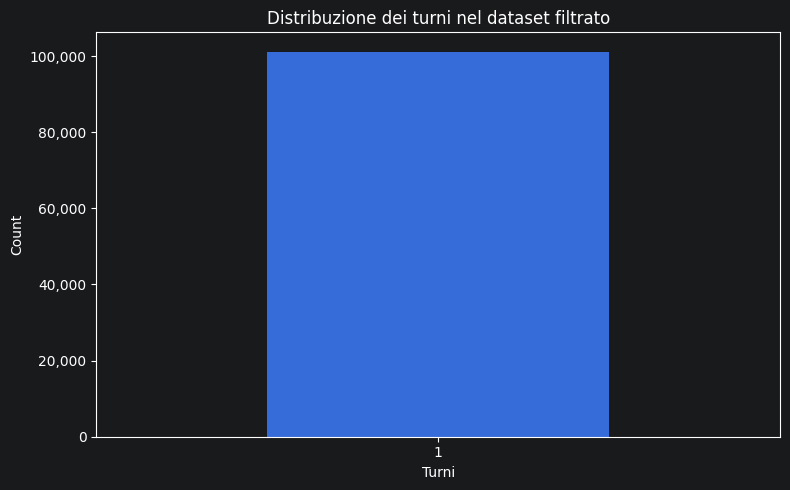

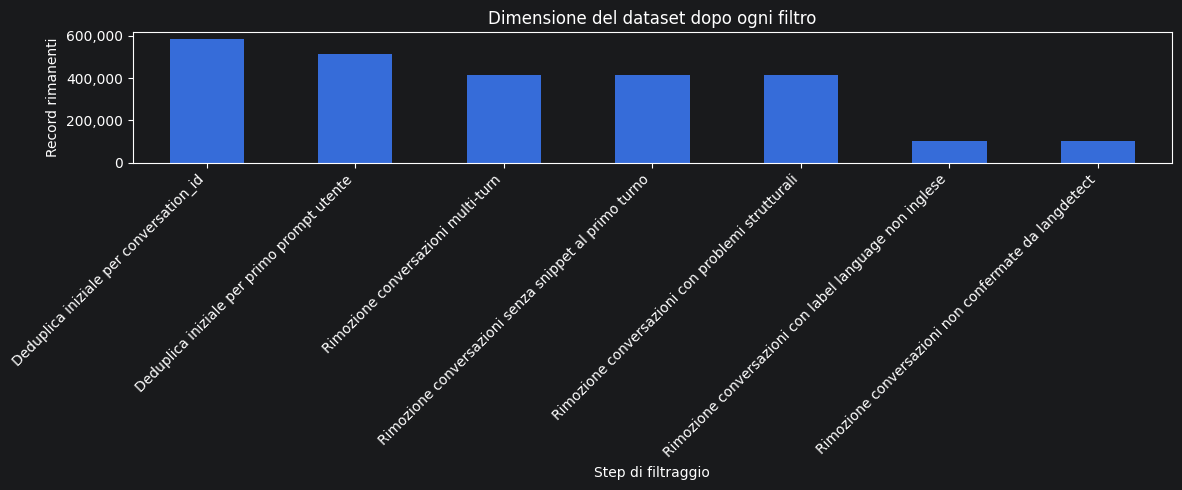

In [29]:
# Grafici essenziali sul dataset filtrato.
if "model" in filtered_meta_df.columns and not filtered_meta_df.empty:
    model_counts_filtered = filtered_meta_df["model"].dropna().astype(str).value_counts().head(25)
    ax = model_counts_filtered.sort_values().plot(kind="barh", figsize=(10, 6))
    ax.set_title("Distribuzione dei modelli nel dataset filtrato")
    ax.set_xlabel("Numero di conversazioni")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "filtered_model_distribution.png", dpi=200, bbox_inches="tight")
    plt.show()

if "turn" in filtered_meta_df.columns and not filtered_meta_df.empty:
    turn_counts_filtered = filtered_meta_df["turn"].dropna().astype(int).value_counts().sort_index()
    ax = turn_counts_filtered.plot(kind="bar", figsize=(8, 5))
    ax.set_title("Distribuzione dei turni nel dataset filtrato")
    ax.set_xlabel("Turni")
    ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "filtered_turn_distribution.png", dpi=200, bbox_inches="tight")
    plt.show()

filtering_plot_df = filtering_steps_df[["step", "records_after"]].copy()
if not filtering_plot_df.empty:
    ax = filtering_plot_df.plot(x="step", y="records_after", kind="bar", legend=False, figsize=(12, 5))
    ax.set_title("Dimensione del dataset dopo ogni filtro")
    ax.set_xlabel("Step di filtraggio")
    ax.set_ylabel("Record rimanenti")
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "filtering_steps_records_after.png", dpi=200, bbox_inches="tight")
    plt.show()
